# 03 — KnowAir: predictive EDA

**Nguồn chính thức:** [PM2.5-GNN repository](https://github.com/shuowang-ai/PM2.5-GNN),
184 thành phố, chu kỳ 3 giờ, 2015–2018. Tensor gồm 17 biến khí tượng
và PM2.5.

Đây là benchmark phù hợp nhất để kiểm tra đồng thời temporal dynamics,
city graph, khoảng cách địa lý và meteorological precursors.

In [1]:
from pathlib import Path
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)
RNG = np.random.default_rng(42)

FEATURES = [
    "100m_u_wind", "100m_v_wind", "2m_dewpoint", "2m_temperature",
    "boundary_layer_height", "k_index", "relative_humidity_950",
    "relative_humidity_975", "specific_humidity_950", "surface_pressure",
    "temperature_925", "temperature_950", "total_precipitation",
    "u_wind_950", "v_wind_950", "vertical_velocity_950",
    "vorticity_950", "PM2.5",
]
array = np.load(ROOT / "data/benchmarks/knowair/KnowAir.npy", mmap_mode="r")
timestamps = pd.date_range("2015-01-01", periods=array.shape[0], freq="3h")
cities = pd.read_csv(
    ROOT / "data/benchmarks/knowair/city.txt", sep=r"\s+",
    names=["id", "city", "lon", "lat"]
)
pm = np.asarray(array[:, :, -1], dtype=np.float32)
overview = pd.Series({
    "shape": str(array.shape), "start": timestamps.min(), "end": timestamps.max(),
    "cities": array.shape[1], "features": array.shape[2],
    "nonfinite values": int((~np.isfinite(array)).sum()),
    "PM2.5 p50": np.nanquantile(pm, .5),
    "PM2.5 p90": np.nanquantile(pm, .9),
    "PM2.5 p99": np.nanquantile(pm, .99),
})
overview

shape                  (11688, 184, 18)
start               2015-01-01 00:00:00
end                 2018-12-31 21:00:00
cities                              184
features                             18
nonfinite values                      0
PM2.5 p50                          40.0
PM2.5 p90                         105.0
PM2.5 p99                         225.0
dtype: object

## Spatial heterogeneity và seasonality

,mean,median,std,p90,p99
city,,,,,
Baoding,86.800003,60.0,79.599998,186.0,388.0
Xingtai,84.199997,62.0,74.000000,169.3,382.0
Shijiazhuang,83.000000,59.0,74.900002,178.0,376.1
Anyang,82.199997,60.0,74.199997,168.3,361.5
Handan,81.599998,61.0,69.699997,164.0,343.3
Hengshui,80.900002,60.0,67.800003,161.0,331.1
Liaocheng,79.199997,62.0,62.299999,153.0,310.0
Jiaozuo,78.300003,58.0,63.900002,156.0,324.1
Zhengzhou,77.300003,56.0,67.000000,159.0,331.1


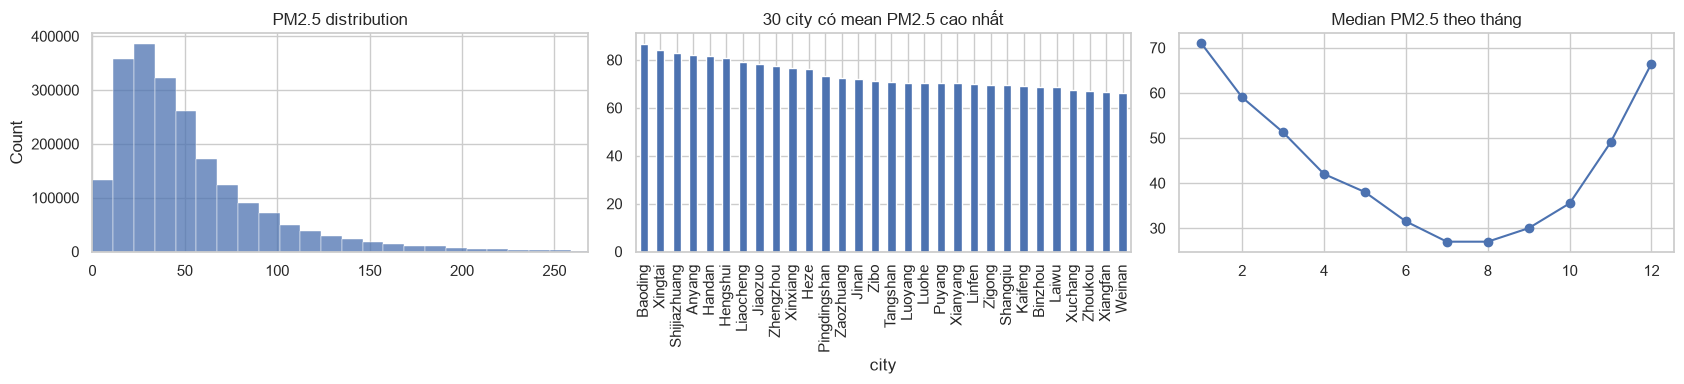

In [2]:
pm_frame = pd.DataFrame(pm, index=timestamps, columns=cities.city)
city_stats = pm_frame.agg(["mean", "median", "std"]).T
city_stats["p90"] = pm_frame.quantile(.9)
city_stats["p99"] = pm_frame.quantile(.99)
monthly = pm_frame.groupby(pm_frame.index.month).median().median(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sns.histplot(pm_frame.stack(), bins=80, ax=axes[0])
axes[0].set(xlim=(0, pm_frame.stack().quantile(.995)), title="PM2.5 distribution")
city_stats["mean"].sort_values(ascending=False).head(30).plot.bar(
    ax=axes[1], title="30 city có mean PM2.5 cao nhất"
)
monthly.plot(marker="o", ax=axes[2], title="Median PM2.5 theo tháng")
plt.tight_layout()
display(city_stats.sort_values("mean", ascending=False).head(20).round(1))

## Persistence, future change và meteorological precursors

In [3]:
sample_t = RNG.choice(array.shape[0] - 8, size=min(2500, array.shape[0] - 8), replace=False)
sample_c = RNG.choice(array.shape[1], size=min(100, array.shape[1]), replace=False)
rows = []
for horizon_step in [1, 2, 8]:
    target_delta = (
        np.asarray(array[sample_t + horizon_step, :, -1])[:, sample_c]
        - np.asarray(array[sample_t, :, -1])[:, sample_c]
    ).ravel()
    feature_matrix = np.asarray(array[sample_t, :, :])[:, sample_c, :].reshape(-1, array.shape[-1])
    sampled = pd.DataFrame(feature_matrix, columns=FEATURES)
    sampled["future_delta"] = target_delta
    corr = sampled.corr(method="spearman")["future_delta"].drop("future_delta")
    for feature, rho in corr.items():
        rows.append((horizon_step * 3, feature, rho))
met_corr = pd.DataFrame(rows, columns=["horizon_h", "feature", "rho"])
top_met = (
    met_corr.assign(abs_rho=lambda x: x.rho.abs())
    .sort_values(["horizon_h", "abs_rho"], ascending=[True, False])
    .groupby("horizon_h").head(8)
)
display(top_met.pivot(index="feature", columns="horizon_h", values="rho").round(3))

horizon_h,3,6,24
feature,,,
100m_v_wind,0.060,0.065,NaN
2m_dewpoint,NaN,-0.048,-0.097
2m_temperature,-0.023,NaN,-0.071
PM2.5,-0.169,-0.249,-0.353
boundary_layer_height,-0.123,NaN,NaN
k_index,-0.022,-0.046,-0.107
relative_humidity_950,NaN,-0.055,NaN
relative_humidity_975,NaN,-0.069,-0.073
specific_humidity_950,NaN,NaN,-0.101


## City context, spatial gap và distance decay

mean    std
horizon_h signal                           
3         other-city trend 3h  0.057  0.108
          own level           -0.182  0.050
          own trend 3h         0.047  0.082
          spatial gap          0.193  0.040
6         other-city trend 3h -0.086  0.105
          own level           -0.266  0.055
          own trend 3h        -0.093  0.086
          spatial gap          0.278  0.046
24        other-city trend 3h  0.038  0.028
          own level           -0.373  0.054
          own trend 3h        -0.108  0.032
          spatial gap          0.435  0.065

mean    std
horizon_h signal                                
3         local spatial gap         0.245  0.061
          local-neighbour trend 3h  0.147  0.103
          own level                -0.182  0.050
          own trend 3h              0.047  0.082
6         local spatial gap         0.314  0.062
          local-neighbour trend 3h  0.021  0.119
          own level                -0.266  0.055
          own trend 3h             -0.093  0.086
24        local spatial gap         0.338  0.069
          local-neighbour trend 3h  0.041  0.042
          own level                -0.373  0.054
          own trend 3h             -0.108  0.032

,count,median,mean
distance_bin,,,
"(0.0, 100.0]",261,0.779,0.767
"(100.0, 300.0]",1690,0.625,0.623
"(300.0, 600.0]",3953,0.461,0.459
"(600.0, 1000.0]",5842,0.335,0.333
"(1000.0, 2000.0]",5083,0.269,0.268
"(2000.0, inf]",7,0.229,0.233


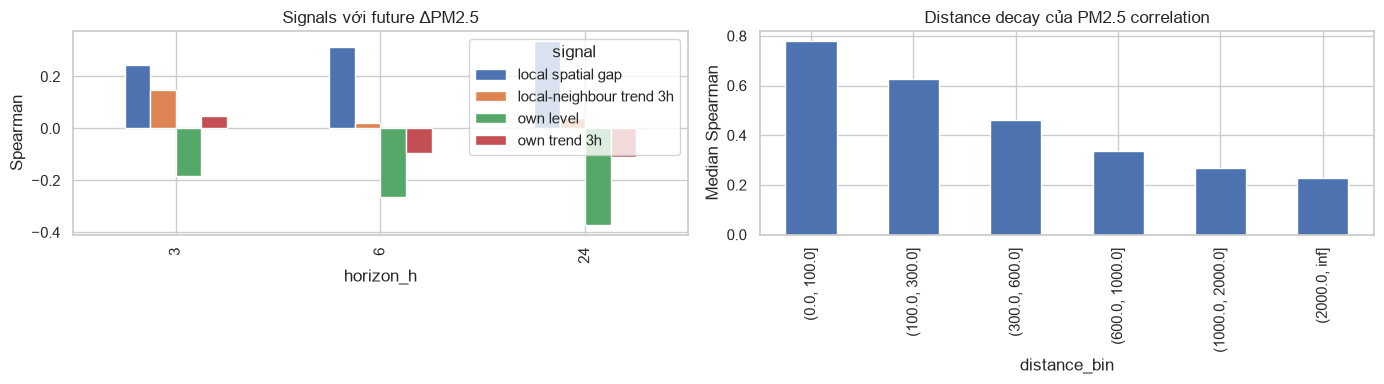

In [4]:
city_mean = pm_frame.mean(axis=1)
rows = []
for city in pm_frame:
    own = pm_frame[city]
    other = (pm_frame.sum(axis=1) - own) / (pm_frame.shape[1] - 1)
    for horizon in [1, 2, 8]:
        delta = own.shift(-horizon) - own
        for signal, values in {
            "own trend 3h": own.diff(),
            "other-city trend 3h": other.diff(),
            "spatial gap": other - own,
            "own level": own,
        }.items():
            rows.append((city, horizon * 3, signal,
                         values.corr(delta, method="spearman")))
spatial = pd.DataFrame(rows, columns=["city", "horizon_h", "signal", "rho"])
spatial_summary = spatial.groupby(["horizon_h", "signal"]).rho.agg(["mean", "std"])

coords = np.radians(cities[["lat", "lon"]].to_numpy())
dlat = coords[:, None, 0] - coords[None, :, 0]
dlon = coords[:, None, 1] - coords[None, :, 1]
a = np.sin(dlat / 2) ** 2 + np.cos(coords[:, None, 0]) * np.cos(coords[None, :, 0]) * np.sin(dlon / 2) ** 2
distance = 6371 * 2 * np.arcsin(np.sqrt(a))
corr_matrix = pm_frame.corr(method="spearman").to_numpy()
upper = np.triu_indices(len(cities), 1)
distance_relation = pd.DataFrame({
    "distance_km": distance[upper], "PM_correlation": corr_matrix[upper]
})
distance_relation["distance_bin"] = pd.cut(
    distance_relation.distance_km, [0, 100, 300, 600, 1000, 2000, np.inf]
)

nearest_10 = np.argsort(distance, axis=1)[:, 1:11]
local_pm = np.nanmean(pm[:, nearest_10], axis=2)
local_rows = []
for city_idx, city in enumerate(pm_frame.columns):
    own = pm_frame[city]
    neighbour = pd.Series(local_pm[:, city_idx], index=pm_frame.index)
    for horizon in [1, 2, 8]:
        delta = own.shift(-horizon) - own
        for signal, values in {
            "own trend 3h": own.diff(),
            "local-neighbour trend 3h": neighbour.diff(),
            "local spatial gap": neighbour - own,
            "own level": own,
        }.items():
            local_rows.append(
                (city, horizon * 3, signal,
                 values.corr(delta, method="spearman"))
            )
local_spatial = pd.DataFrame(
    local_rows, columns=["city", "horizon_h", "signal", "rho"]
)
local_spatial_summary = local_spatial.groupby(
    ["horizon_h", "signal"]
).rho.agg(["mean", "std"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
local_spatial.groupby(["horizon_h", "signal"]).rho.mean().unstack().plot.bar(ax=axes[0])
axes[0].set(title="Signals với future ΔPM2.5", ylabel="Spearman")
distance_relation.groupby("distance_bin", observed=True).PM_correlation.median().plot.bar(ax=axes[1])
axes[1].set(title="Distance decay của PM2.5 correlation", ylabel="Median Spearman")
plt.tight_layout()
display(spatial_summary.round(3).rename_axis(index={None: "global context"}))
display(local_spatial_summary.round(3))
display(distance_relation.groupby("distance_bin", observed=True).PM_correlation.agg(["count", "median", "mean"]).round(3))

## Spike onset và temporal shift

In [5]:
train_cut = len(pm_frame) // 2
threshold = np.nanquantile(pm_frame.iloc[:train_cut].to_numpy(), .90)
future_max = pd.DataFrame(
    np.nanmax(np.stack([pm_frame.shift(-lead).to_numpy()
                       for lead in range(1, 9)]), axis=0),
    index=pm_frame.index, columns=pm_frame.columns,
)
eligible = pm_frame.lt(threshold) & future_max.notna()
onset = future_max.ge(threshold) & pm_frame.lt(threshold)
ratio = pm_frame / threshold
onset_rows = []
for low, high in zip([0, .25, .5, .75], [.25, .5, .75, 1]):
    mask = eligible & ratio.ge(low) & ratio.lt(high)
    onset_rows.append({
        "current/train_p90": f"{low:.2f}–{high:.2f}",
        "observations": int(mask.sum().sum()),
        "onset_24h_pct": onset.where(mask).stack().mean() * 100,
    })
onset_table = pd.DataFrame(onset_rows)

yearly = []
for year, values in pm_frame.groupby(pm_frame.index.year):
    delta24 = values.shift(-8) - values
    yearly.append({
        "year": year, "mean": values.stack().mean(),
        "p90": values.stack().quantile(.9), "p99": values.stack().quantile(.99),
        "|delta24|_p90": delta24.stack().abs().quantile(.9),
    })
display(onset_table.round(2))
display(pd.DataFrame(yearly).set_index("year").round(2))

/var/folders/jb/67wsnbtn2z94g_rpvyrhmd800000gn/T/ipykernel_93539/3326152999.py:4: RuntimeWarning: All-NaN slice encountered
  np.nanmax(np.stack([pm_frame.shift(-lead).to_numpy()


,current/train_p90,observations,onset_24h_pct
0,0.00–0.25,672357,2.17
1,0.25–0.50,771837,7.09
2,0.50–0.75,357835,24.45
3,0.75–1.00,163575,54.41


,mean,p90,p99,|delta24|_p90
year,,,,
2015,58.430000,116.0,243.0,67.0
2016,54.130001,109.0,233.0,61.0
2017,51.240002,101.0,223.0,58.0
2018,46.060001,91.0,199.0,50.0


In [6]:
display(Markdown(f'''
## Kết luận có thể dùng cho model

- KnowAir không có missing value gốc trong tensor phát hành; kết quả trên benchmark
  này không kiểm chứng được robustness với sensor outage.
- Local-neighbour trend tại +3h đạt
  `rho={local_spatial_summary.loc[(3, "local-neighbour trend 3h"), "mean"]:.3f}`;
  local spatial gap tăng tới
  `rho={local_spatial_summary.loc[(24, "local spatial gap"), "mean"]:.3f}` ở +24h.
- PM correlation giảm theo khoảng cách nhưng không biến mất ở khoảng cách lớn:
  graph cần local edges và một city/national context, không chỉ một trong hai.
- Meteorological relations đổi theo horizon; wind vector, boundary-layer height
  và humidity nên được kiểm tra theo regime thay vì chỉ global correlation.
'''))


## Kết luận có thể dùng cho model

- KnowAir không có missing value gốc trong tensor phát hành; kết quả trên benchmark
  này không kiểm chứng được robustness với sensor outage.
- Local-neighbour trend tại +3h đạt
  `rho=0.147`;
  local spatial gap tăng tới
  `rho=0.338` ở +24h.
- PM correlation giảm theo khoảng cách nhưng không biến mất ở khoảng cách lớn:
  graph cần local edges và một city/national context, không chỉ một trong hai.
- Meteorological relations đổi theo horizon; wind vector, boundary-layer height
  và humidity nên được kiểm tra theo regime thay vì chỉ global correlation.


## Standardized cross-benchmark diagnostics

Các bảng dưới đây dùng cùng định nghĩa horizon, station-specific
train p90, train IQR, chronological split và mask-aware correlation.
Chúng giúp phân biệt quan sát lặp lại giữa benchmark với đặc điểm chỉ
có ở dataset này. Kết quả là mô tả dữ liệu, không phải causal claim
hay quyết định kiến trúc.

`spatial_gap_partial_current` quan trọng hơn raw spatial-gap
correlation vì đã giảm tương quan cơ học do cả spatial gap và target
change cùng chứa giá trị PM hiện tại.

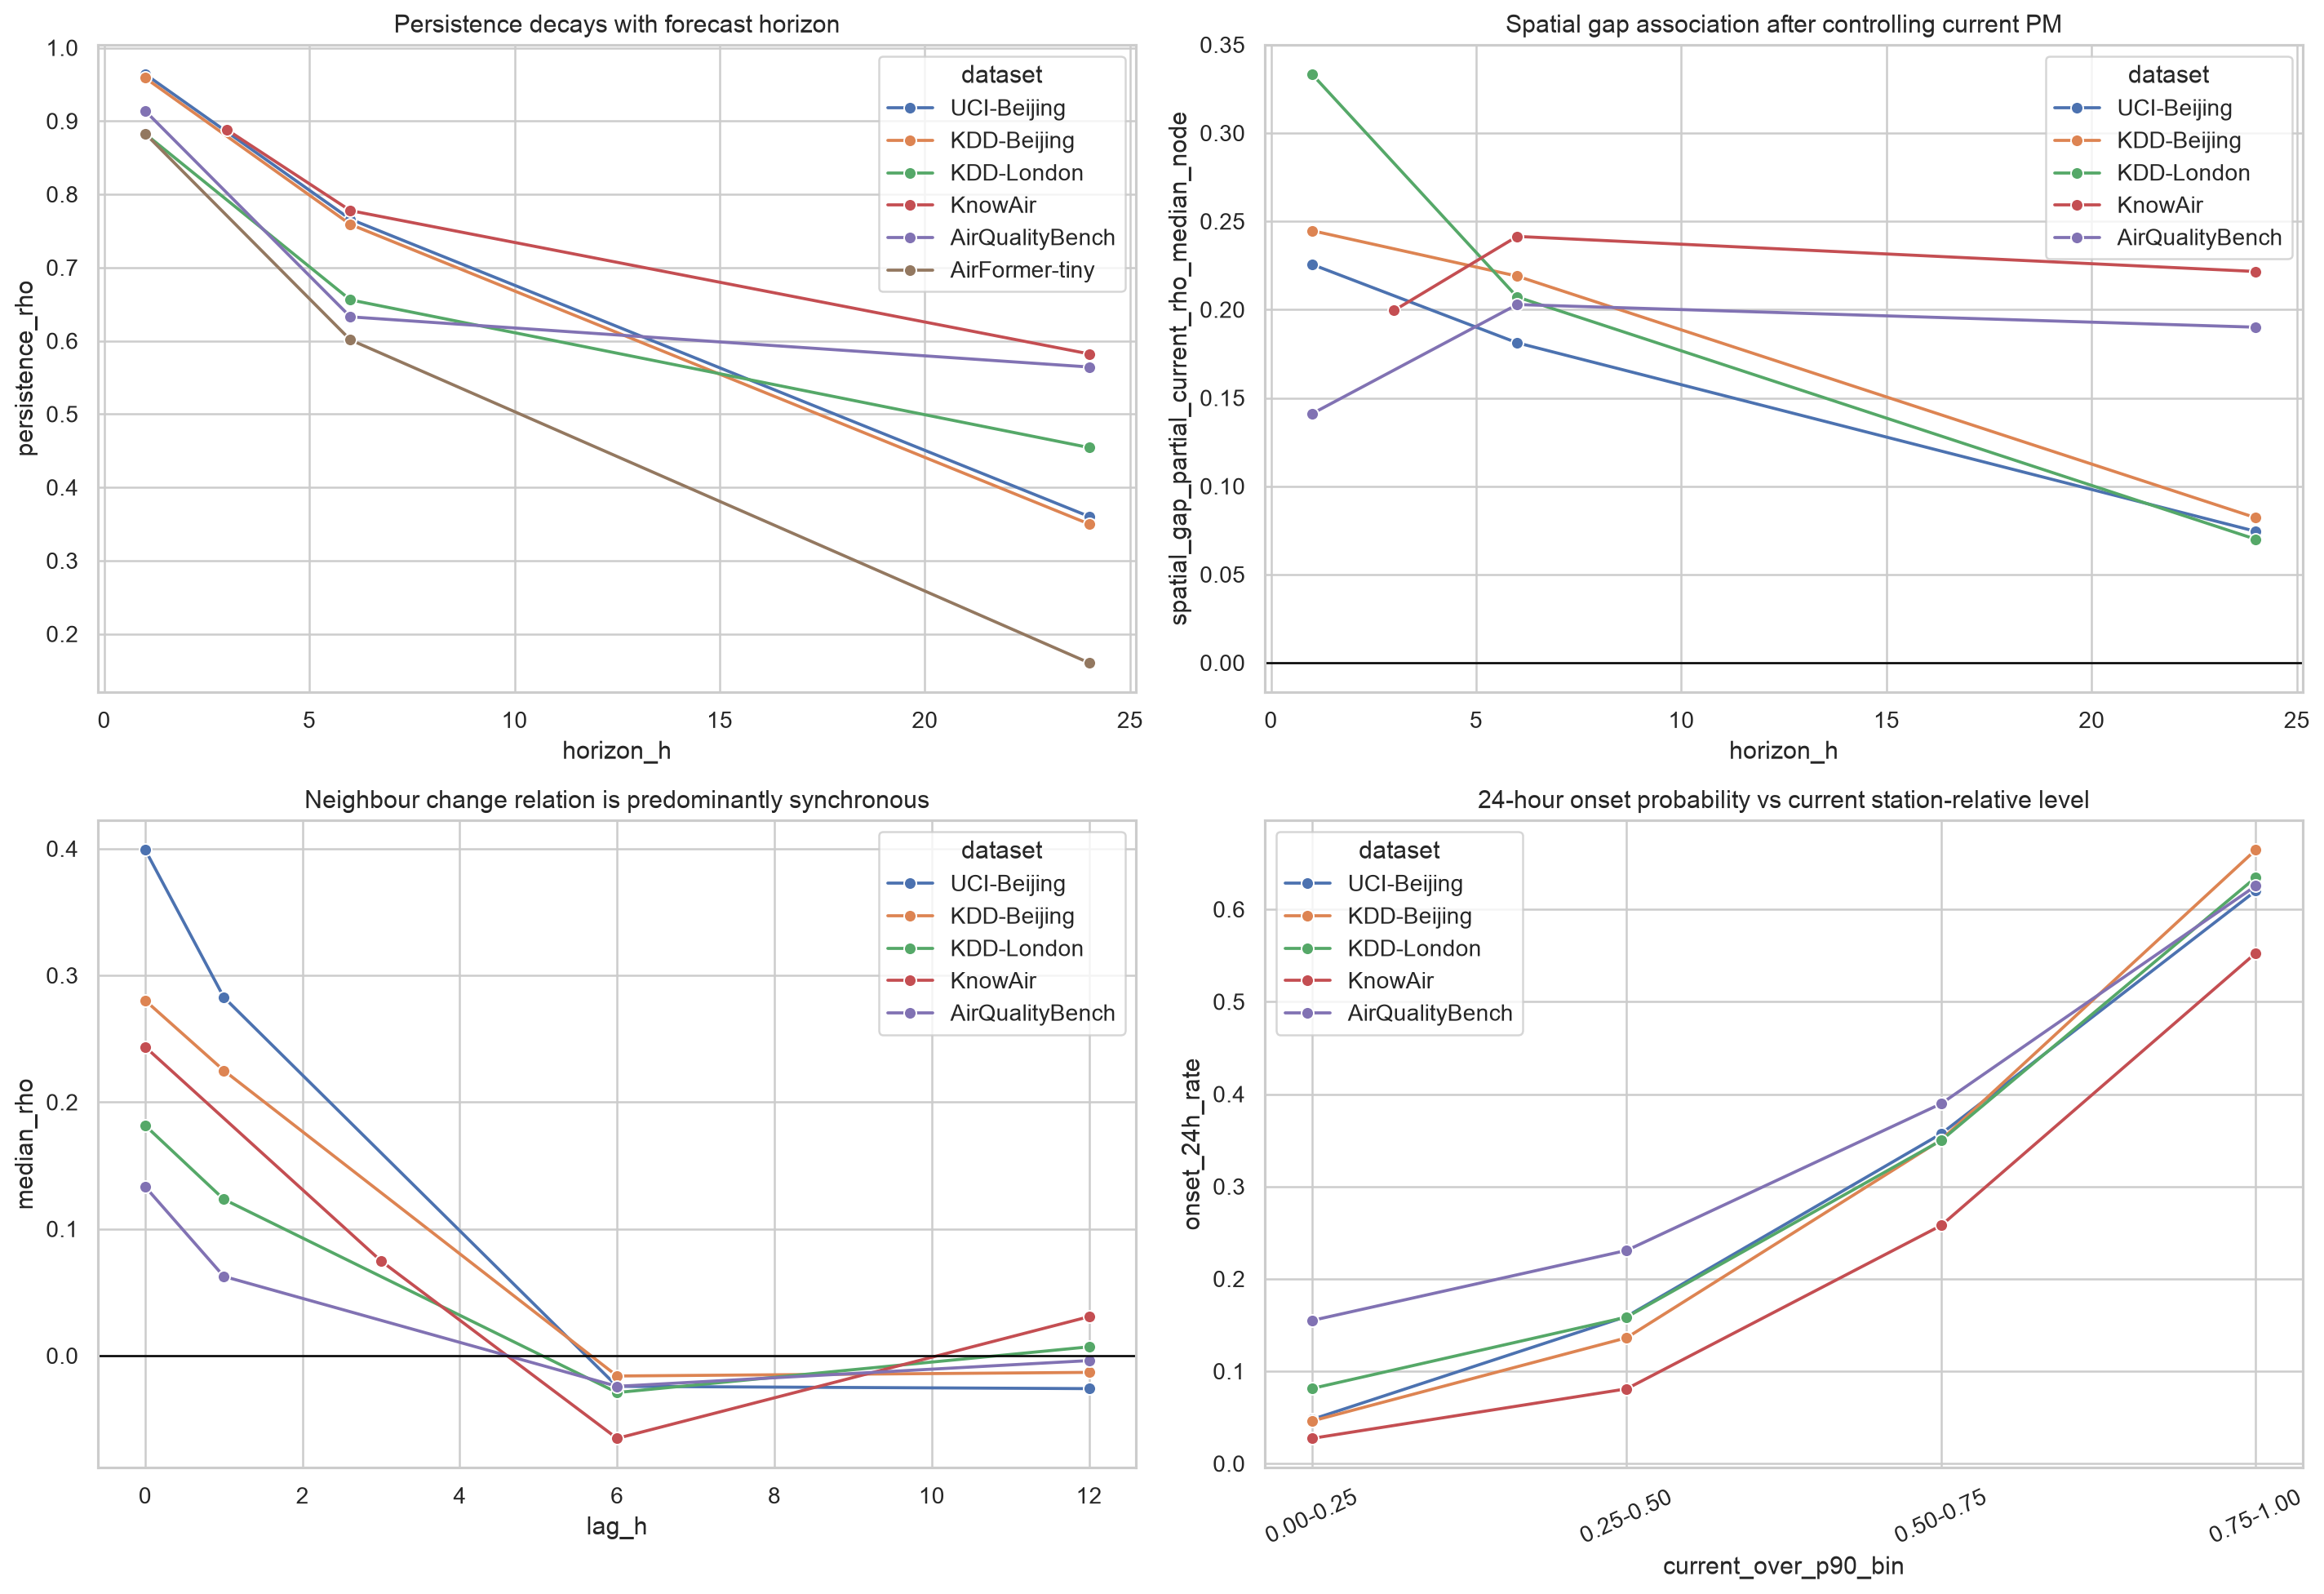

,dataset,scope,time_steps,nodes,cadence_h,start,end,coverage_mean,coverage_node_p10,coverage_node_p90,pm_p50,pm_p90,pm_p99,tail_p99_over_p90
3,KnowAir,"China, 184 cities",11688,184,3,2015-01-01 00:00:00,2018-12-31 21:00:00,1.0,1.0,1.0,40.0,105.0,225.0,2.143


,dataset,horizon_h,persistence_rho,persistence_mae_over_train_iqr,current_level_vs_future_change_rho,own_recent_trend_rho_median_node,neighbour_recent_trend_rho_median_node,spatial_gap_rho_median_node,spatial_gap_partial_current_rho_median_node,cross_node_mean_component_share
9,KnowAir,3,0.888,0.167,-0.165,0.049,0.168,0.249,0.200,0.103
10,KnowAir,6,0.778,0.256,-0.244,-0.087,0.058,0.321,0.241,0.121
11,KnowAir,24,0.582,0.375,-0.350,-0.109,0.047,0.343,0.222,0.113


,dataset,event_rate_test,local_event_coherence,local_event_expected_if_time_independent,local_event_lift_over_independent,active_node_fraction_median,active_node_fraction_p90,spike_duration_h_median,spike_duration_h_p90,coverage_mean,...,seasonal_amplitude_over_iqr,diurnal_amplitude_over_iqr,weekend_minus_weekday_over_iqr,node_median_spread_over_global_iqr,native_change_up_p99_over_down_p99,test_minus_train_median_over_train_iqr,current_over_p90_bin,n,onset_24h_rate,limitation
15,KnowAir,0.041,0.454,0.043,10.547,0.022,0.266,6.0,27.0,1.0,...,1.036,0.262,0.012,0.226,0.875,-0.25,NaN,NaN,NaN,NaN


,dataset,current_over_p90_bin,n,onset_24h_rate
16,KnowAir,0.00-0.25,582325.0,0.027
17,KnowAir,0.25-0.50,771783.0,0.081
18,KnowAir,0.50-0.75,400779.0,0.258
19,KnowAir,0.75-1.00,189073.0,0.553


,dataset,lag_h,edge_count,median_rho,mean_rho,best_lag_zero_edge_fraction
12,KnowAir,0,400,0.244,0.249,0.95
13,KnowAir,3,400,0.075,0.074,0.95
14,KnowAir,6,400,-0.065,-0.073,0.95
15,KnowAir,12,400,0.031,0.037,0.95


,dataset,pair_count,distance_vs_level_rho,distance_vs_native_change_rho
2,KnowAir,1000,-0.738,-0.516


,dataset,lag_h,pair_count,mean,median,std,positive_pair_fraction
5,KnowAir,0,400,-0.012,-0.017,0.086,0.438
6,KnowAir,3,400,0.071,0.078,0.094,0.778
7,KnowAir,6,400,0.066,0.062,0.091,0.762
8,KnowAir,12,400,0.011,0.013,0.058,0.598


,dataset,pollutant,horizon_h,level_rho_median_node,native_change_rho_median_node,current_pollutant_vs_future_pm_change_rho_median_node,partial_current_pm_rho_median_node


,dataset,feature,horizon_h,rho_median_node,partial_current_pm_rho_median_node
14,KnowAir,temperature,6,-0.004,-0.106
15,KnowAir,temperature,24,-0.081,-0.241
16,KnowAir,pressure,6,0.001,0.072
17,KnowAir,pressure,24,0.090,0.217
18,KnowAir,dewpoint,6,-0.045,-0.145
19,KnowAir,dewpoint,24,-0.109,-0.261
20,KnowAir,precipitation,6,-0.058,-0.119
21,KnowAir,precipitation,24,-0.059,-0.142
22,KnowAir,wind_speed,6,-0.058,-0.107
23,KnowAir,wind_speed,24,-0.015,-0.076


In [7]:
from IPython.display import Image

cross_dir = ROOT / "artifacts/cross_dataset_eda"
labels = ['KnowAir']
overview_cross = pd.read_csv(cross_dir / "dataset_overview.csv")
horizon_cross = pd.read_csv(cross_dir / "horizon_signals.csv")
events_cross = pd.read_csv(cross_dir / "events_missingness_shift.csv")
edge_cross = pd.read_csv(cross_dir / "edge_lead_lag.csv")
distance_cross = pd.read_csv(cross_dir / "distance_decay_summary.csv")
wind_cross = pd.read_csv(cross_dir / "wind_alignment_replication.csv")
coupling_cross = pd.read_csv(cross_dir / "pollutant_coupling.csv")
meteo_cross = pd.read_csv(cross_dir / "meteorology_precursors.csv")

display(Image(filename=str(cross_dir / "cross_dataset_main.png"), width=1100))
display(overview_cross.query("dataset in @labels").round(3))
display(horizon_cross.query("dataset in @labels").round(3))
display(events_cross.query("dataset in @labels and current_over_p90_bin != current_over_p90_bin").round(3))
display(events_cross.query("dataset in @labels and current_over_p90_bin == current_over_p90_bin")[[
    "dataset", "current_over_p90_bin", "n", "onset_24h_rate"
]].round(3))
display(edge_cross.query("dataset in @labels").round(3))
display(distance_cross.query("dataset in @labels").round(3))
display(wind_cross.query("dataset in @labels").round(3))
display(coupling_cross.query("dataset in @labels").round(3))
display(meteo_cross.query("dataset in @labels").round(3))

Báo cáo diễn giải đầy đủ nằm tại
`artifacts/cross_dataset_eda/OBSERVATIONS.md`. Các ô trống có nghĩa là
phép đo không hợp lệ hoặc không khả dụng trên release này; không được
diễn giải thành “không có hiệu ứng”.